# Continuation of Lyapunov and Halo Orbit Families

This example computes and visualizes families of periodic orbits in the Earth-Moon Circular Restricted Three-Body Problem (CR3BP) using own continuation codes.

The workflow is:

1. Compute the Lagrange points.
2. Obtain an initial guess for a planar Lyapunov orbit around L2.
3. Correct the initial condition using differential correction.
4. Continue the Lyapunov family.
5. Use the bifurcation point to generate a Halo orbit seed.
6. Continue the Halo family toward Near-Rectilinear Halo Orbits (NRHOs).
7. Integrate and visualize representative members of both families.
8. Characterize a selected NRHO in terms of period, resonance, perilune and apolune.

## Imports & Configuration


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from fractions import Fraction
from pathlib import Path
import sys

In [2]:
REPO_ROOT = Path.cwd().resolve().parents[2]

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [3]:
from py.modules.solvers.RK45 import rk45
from py.modules.cislunar_astrodynamics.cr3bp_engine import (
    cr3bp,
    find_L_points,
    eigenvalues_on_L_points,
)

from py.modules.cislunar_astrodynamics.lyapunov_halo_engine import *

## Problem initialization

We first compute the Lagrange points and obtain the linearized dynamics
around the L2 equilibrium point. The corresponding eigenstructure is used
to construct an initial guess for a planar Lyapunov orbit.

In [4]:
orbits = []

L1, L2, L3 = find_L_points(MU)

print(f"L1 = {L1:.6f}")
print(f"L2 = {L2:.6f}")
print(f"L3 = {L3:.6f}")

L1 = 0.836918
L2 = 1.155680
L3 = -1.005062


## Linear analysis around L2

The eigenvalues and eigenvectors of the linearized CR3BP dynamics at L2 are computed. The eigenvector associated with the imaginary eigenvalue provides the direction used to generate the initial Lyapunov orbit seed.

In [5]:
_, l2_eigen_solution, _ = eigenvalues_on_L_points(MU)

eigenvalues_l2, eigenvectors_l2 = l2_eigen_solution

seed_eigenvalue = eigenvalues_l2[2]
seed_eigenvector = eigenvectors_l2[:, 2]

print("Selected eigenvalue:")
print(seed_eigenvalue)

Selected eigenvalue:
1.8626489826065784j


In [6]:
seed_direction = np.real(seed_eigenvector)
seed_direction /= np.linalg.norm(seed_direction)

period_guess = 2.0 * np.pi / abs(seed_eigenvalue.imag)

perturbation_amplitude = 5e-3

print(f"Estimated period: {period_guess:.6f}")
print(f"Perturbation amplitude: {perturbation_amplitude:.2e}")

Estimated period: 3.373252
Perturbation amplitude: 5.00e-03


The initial perturbation is obtained from the real part of the selected eigenvector. Its amplitude is kept small so that the resulting state remains close to the L2 equilibrium point, where the linear approximation is valid.

In [7]:
x0_seed = L2 + perturbation_amplitude * seed_direction[0]
ydot0_seed = perturbation_amplitude * seed_direction[4]

print(f"x0 seed    = {x0_seed:.8f}")
print(f"ydot0 seed = {ydot0_seed:.8f}")

x0 seed    = 1.15658627
ydot0 seed = -0.00491716


## Differential correction

The linear approximation provides only an initial guess. A differential correction procedure is therefore used to enforce the periodicity conditions of the Lyapunov orbit.

In [8]:
x0_corrected, ydot0_corrected, half_period, _ = differential_corrector(
    x0=x0_seed,
    ydot0=ydot0_seed,
    mu=MU,
    period_guess=period_guess / 2.0,
    verbose=False,
)

print(
    f"Corrected Lyapunov orbit:\n"
    f"  x0         = {x0_corrected:.6f}\n"
    f"  ydot0      = {ydot0_corrected:.6f}\n"
    f"  half period = {half_period:.6f}"
)

Corrected Lyapunov orbit:
  x0         = 1.156583
  ydot0      = -0.004918
  half period = 1.686643


In [9]:
orbits.append(
    OrbitData(
        x0=x0_corrected,
        ydot0=ydot0_corrected,
        T_half=half_period,
    )
)

## Lyapunov family continuation

Starting from the corrected Lyapunov orbit, the family is computed using numerical continuation.

The continuation modifies the initial condition gradually while applying differential correction at each step. The process is stopped when the specified bifurcation condition is reached.

In [10]:
lyapunov_family, _ = compute_lyapunov_family(
    x0_start=x0_corrected,
    ydot0_start=ydot0_corrected,
    initial_period=half_period * 2.0,
    mu=MU,
    number_of_orbits=15,
    x0_step=3e-3,
    stop_at_bifurcation=True,
    verbose=False,
)

orbits.extend(lyapunov_family)

print(f"Number of Lyapunov orbits: {len(orbits)}")

Number of Lyapunov orbits: 11


## Lyapunov-to-Halo bifurcation

The last orbit returned by the Lyapunov continuation is used as the bifurcation orbit from which the three-dimensional Halo family is seeded.

In [11]:
bifurcation_orbit = orbits[-1]
bifurcation_orbit_index = len(orbits) - 1

print(f"Bifurcation orbit index: {bifurcation_orbit_index}")
print(f"Bifurcation orbit x0: {bifurcation_orbit.x0:.6f}")
print(f"Bifurcation orbit T/2: {bifurcation_orbit.T_half:.6f}")

Bifurcation orbit index: 10
Bifurcation orbit x0: 1.183257
Bifurcation orbit T/2: 1.713825


## Halo orbit initialization

A small out-of-plane perturbation is introduced at the Lyapunov
bifurcation orbit to generate an initial three-dimensional Halo orbit
seed.

In [12]:
x0, z0, ydot0 = build_halo_seed(
    bifurcation_orbit,
    vertical_perturbation=-5e-2,
)

initial_state = build_state_vector(
    x0,
    z0,
    ydot0,
    bifurcation_orbit.T_half,
)

print("Initial Halo state:")
print(initial_state)


Vertical-mode eigenvector (real part):
  [0] x    = +0.000000
  [1] y    = -0.000000
  [2] z    = +0.821324
  [3] xdot = -0.000000
  [4] ydot = -0.000000
  [5] zdot = +0.570462

Selected eigenvalue : +0.87665090+0.00000000j
Vertical position component : +0.821324
Vertical velocity component : +0.570462

Vertical perturbation = -5.00e-02
Scaling factor        = -0.050000

Halo initial guess:
  x0    = 1.1832565038 (Δ = -1.6175e-15)
  z0    = -0.0410662146
  ydot0 = -0.1734834686 (Δ = +8.6530e-15)
Initial Halo state:
[ 1.1832565  -0.04106621 -0.17348347  1.71382528]


## Halo family continuation

The Halo family is continued using adaptive step sizes. The continuation is stopped according to the specified perilune and numerical limits.

In [13]:
halo_family = compute_halo_family(
    initial_state,
    MU,
    initial_step_size=5e-4,
    maximum_step_size=1.5e-2,
    minimum_step_size=1e-8,
    target_perilune_km=1800.0,
    max_steps=20000,
    orientation_hint=np.sign(initial_state[1]),
    verbose=False,
)

orbits.extend(halo_family)

print(f"Total number of orbits: {len(orbits)}")
print(f"Number of Halo orbits: {len(halo_family)}")

Total number of orbits: 97
Number of Halo orbits: 86


## Orbit selection

Only representative members of the families are plotted to avoid
overcrowding the figure.

The selected orbits include:
- the initial Lyapunov orbit,
- intermediate Lyapunov orbits,
- the Lyapunov-to-Halo bifurcation orbit,
- and the final Halo/NRHO-like orbit.

In [14]:
n = len(orbits)

selected_indices = [
    i
    for i in range(n)
    if (
        i == 1
        or i == 2
        or i >= n - 2
        or i % 5 == 0
        or i == bifurcation_orbit_index
    )
]

selected_indices

[0,
 1,
 2,
 5,
 10,
 15,
 20,
 25,
 30,
 35,
 40,
 45,
 50,
 55,
 60,
 65,
 70,
 75,
 80,
 85,
 90,
 95,
 96]

## Orbit propagation

Each selected initial condition is propagated over one complete orbital period using the CR3BP equations of motion and the adaptive RK45 solver.

In [15]:
propagated_orbits = {}

for i in selected_indices:

    orbit = orbits[i]

    state_vector = np.array([
        orbit.x0,
        orbit.y0,
        orbit.z0,
        orbit.xdot0,
        orbit.ydot0,
        orbit.zdot0,
    ])

    period = 2.0 * orbit.T_half

    sol = rk45(
        fun=cr3bp,
        t_span=(0, period),
        Y0=state_vector,
        args=(MU,),
        h0=5e-4,
        h_min=1e-8,
        h_max=5e-3,
        h_adaptative=True,
    )

    propagated_orbits[i] = sol

## Three-dimensional visualization

The propagated trajectories are plotted in the normalized CR3BP
coordinate system. The Moon and the L2 point are also displayed for
reference.

In [16]:
def plot_orbit_families(orbits, propagated_orbits, bifurcation_index):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    n = len(orbits)

    for i, sol in propagated_orbits.items():

        pos = sol.y[:3]

        if i == 2:
            color = "green"
            alpha = 1.0
            label = "Initial Lyapunov"

        elif i == bifurcation_index:
            color = "blue"
            alpha = 1.0
            label = "Bifurcation (Lyapunov to Halo)"

        elif i == n - 2:
            color = "tab:red"
            alpha = 1.0
            label = "NRHO"

        else:
            color = "lightgray"
            alpha = 0.8
            label = None

        ax.plot(
            pos[0],
            pos[1],
            pos[2],
            color=color,
            alpha=alpha,
            linewidth=1.5,
            label=label,
        )

    moon = (1 - MU, 0, 0)

    ax.scatter(*moon, color="gray", s=80)
    ax.text(*moon, "Moon")

    _, L2_x, _ = find_L_points(MU)

    L2_position = (L2_x, 0, 0)

    ax.scatter(
        *L2_position,
        color="black",
        marker="*",
        s=120,
    )

    ax.text(*L2_position, "L2")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    ax.legend()
    plt.tight_layout()
    plt.show()

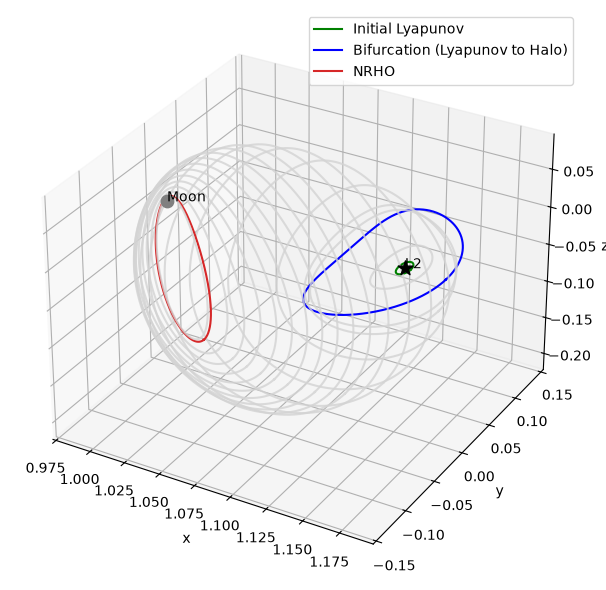

In [17]:
plot_orbit_families(
    orbits,
    propagated_orbits,
    bifurcation_orbit_index,
)

## NRHO characterization

The selected Halo orbit is characterized using its dimensional orbital
period and its perilune/apolune distances.

The period is compared with the lunar orbital period to identify a nearby integer resonance.

In [18]:
nrho_index = n - 2
nrho_orbit = orbits[nrho_index]

lunar_period = 27.321661

nrho_period_days = (
    nrho_orbit.T_half * 2.0 * TU_DAYS
)

ratio = nrho_period_days / lunar_period

resonance = Fraction(ratio).limit_denominator(20)

print(f"NRHO period: {nrho_period_days:.3f} days")
print(f"Period ratio: {ratio:.6f}")
print(f"Resonance: {resonance}")

NRHO period: 6.046 days
Period ratio: 0.221308
Resonance: 2/9


In [19]:
state_vector = np.array([
    nrho_orbit.x0,
    nrho_orbit.z0,
    nrho_orbit.ydot0,
    nrho_orbit.T_half,
])

perilune, apolune = compute_orbit_extrema(
    state_vector,
    MU,
)

print(f"Perilune: {perilune:.1f} km")
print(f"Apolune:  {apolune:.1f} km")

Perilune: 1995.7 km
Apolune:  67959.2 km


## Results

The continuation procedure successfully generates a sequence of planar
Lyapunov orbits around L2 and follows the family up to the
Lyapunov-to-Halo bifurcation.

Starting from the bifurcation orbit, the continuation is extended into
the three-dimensional Halo family. A representative NRHO-like orbit is
then identified and characterized by its orbital period, resonance,
perilune and apolune distances.

In [20]:
results = {
    "Number of Lyapunov orbits": len(lyapunov_family) + 1,
    "Number of Halo orbits": len(halo_family),
    "NRHO period [days]": nrho_period_days,
    "Resonance": str(resonance),
    "Perilune [km]": perilune,
    "Apolune [km]": apolune,
}

results

{'Number of Lyapunov orbits': 11,
 'Number of Halo orbits': 86,
 'NRHO period [days]': np.float64(6.046496361205327),
 'Resonance': '2/9',
 'Perilune [km]': 1995.6960682009997,
 'Apolune [km]': 67959.22811495836}